In [1]:
from dgl import from_networkx
import dgl
import torch.nn as nn
import torch as th
import torch.nn.functional as F
import dgl.function as fn
import networkx as nx
import pandas as pd
import socket
import struct
import random
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import category_encoders as ce
import numpy as np
from sklearn.utils import class_weight

In [2]:
data = pd.read_csv('NF-BoT-IoT-v2-0.03.csv')
data['IPV4_SRC_ADDR'] = data.IPV4_SRC_ADDR.apply(lambda x: socket.inet_ntoa(struct.pack('>I', random.randint(0xac100001, 0xac1f0001))))
data['IPV4_SRC_ADDR'] = data.IPV4_SRC_ADDR.apply(str)
data['L4_SRC_PORT'] = data.L4_SRC_PORT.apply(str)
data['IPV4_DST_ADDR'] = data.IPV4_DST_ADDR.apply(str)
data['L4_DST_PORT'] = data.L4_DST_PORT.apply(str)
data['IPV4_SRC_ADDR'] = data['IPV4_SRC_ADDR'] + ':' + data['L4_SRC_PORT']
data['IPV4_DST_ADDR'] = data['IPV4_DST_ADDR'] + ':' + data['L4_DST_PORT']
data.drop(columns=['L4_SRC_PORT','L4_DST_PORT'],inplace=True)
data.drop(columns=['Attack'],inplace = True)
data.rename(columns={"Label": "label"},inplace = True)
label = data.label
scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(data, label, test_size=0.3, random_state=123,stratify= label)
cols_to_norm = [c for c in X_train.columns[2:] if c != 'label']

X_train[cols_to_norm] = scaler.fit_transform(X_train[cols_to_norm])
X_train['h'] = X_train[ cols_to_norm ].values.tolist()
feature_names = cols_to_norm 
G = nx.from_pandas_edgelist(X_train, "IPV4_SRC_ADDR", "IPV4_DST_ADDR", ['h','label'],create_using=nx.MultiGraph())
G = G.to_directed()
G = from_networkx(G,edge_attrs=['h','label'] )
G.ndata['h'] = th.ones(G.num_nodes(), G.edata['h'].shape[1])

X_test[cols_to_norm] = scaler.fit_transform(X_test[cols_to_norm])
X_test['h'] = X_test[ cols_to_norm ].values.tolist()
G_test = nx.from_pandas_edgelist(X_test, "IPV4_SRC_ADDR", "IPV4_DST_ADDR", ['h','label'],create_using=nx.MultiGraph())
G_test = G_test.to_directed()
G_test = from_networkx(G_test,edge_attrs=['h','label'] )
G_test.ndata['h'] = th.ones(G_test.num_nodes(), G_test.edata['h'].shape[1])

In [3]:
device = th.device('cuda' if th.cuda.is_available() else 'cpu')
graphs, _ = dgl.load_graphs('train_b.bin')
G = graphs[0]

In [4]:
G = G.to(device)
node_features = G.ndata['h']
edge_features = G.edata['h']
edge_label = G.edata['label']


In [5]:
def compute_accuracy(pred, labels):
    return (pred.argmax(1) == labels).float().mean().item()

class SAGELayer(nn.Module):
    def __init__(self, ndim_in, edims, ndim_out ):
        super(SAGELayer, self).__init__()
        ### force to outut fix dimensions
        self.W_msg = nn.Linear(ndim_in + edims, ndim_out)
        ### apply weight
        self.W_apply = nn.Linear(ndim_in + ndim_out, ndim_out)
        

    def message_func(self, edges):
        return {'m': self.W_msg(th.cat([edges.data['h'], edges.dst['h']], 1))}

    def forward(self, g_dgl, nfeats, efeats):
        with g_dgl.local_scope():
            g = g_dgl
            g.ndata['h'] = nfeats
            g.edata['h'] = efeats
            # Eq4
            g.update_all(self.message_func, fn.mean('m', 'h_neigh'))
            # Eq5          
            g.ndata['h'] = F.relu(self.W_apply(th.cat([g.ndata['h'], g.ndata['h_neigh']], 1)))
            return g.ndata['h']

class MLPPredictor(nn.Module):
    def __init__(self, in_features, edim, out_classes):
        super().__init__()
        self.W = nn.Linear(in_features * 2 + edim, out_classes)

    def apply_edges(self, edges):
        h_u = edges.src['h']
        h_v = edges.dst['h']
        h_e = edges.data['h']
        score = self.W(th.cat([h_u, h_e, h_v], 1))
        return {'score': score}

    def forward(self, graph, h, efeats):
        with graph.local_scope():
            graph.ndata['h'] = h
            graph.edata['h'] = efeats
            graph.apply_edges(self.apply_edges)
            return graph.edata['score']

class Model(nn.Module):
    def __init__(self,  ndim_in, ndim_out, edim):
        super().__init__()
        self.atten = nn.Parameter(th.randn(1, edim))
        self.cov1 = SAGELayer(ndim_in, edim, ndim_out)
        self.cov2 = SAGELayer(ndim_out, edim, ndim_out)
        self.pred = MLPPredictor(ndim_out, edim, 2)
        self.dropout = nn.Dropout(p=0.2)
        
    def forward(self, g, nfeats, efeats):
        efeats = efeats * self.atten
        nfeats = F.relu(self.cov1(g, nfeats, efeats))
        nfeats = self.dropout(nfeats)
        nfeats = F.relu(self.cov2(g, nfeats, efeats))
        nfeats = self.dropout(nfeats)
        return self.pred(g, nfeats, efeats)


In [6]:
criterion = nn.CrossEntropyLoss()
model = Model( G.ndata['h'].shape[1], 64, G.edata['h'].shape[1]).to(device)
opt = th.optim.Adam(model.parameters())

In [7]:
for epoch in range(500):
    pred = model( G, node_features, edge_features)
    loss = criterion(pred ,edge_label)
    opt.zero_grad()
    loss.backward()
    opt.step()
    if (epoch+1) % 100 == 0:
      print('Training acc:', compute_accuracy(pred, edge_label))

Training acc: 0.9984855651855469
Training acc: 0.9987944960594177
Training acc: 0.9989533424377441
Training acc: 0.9990233778953552
Training acc: 0.9990176558494568


In [8]:

with th.no_grad():
    w = model.atten.detach().cpu().numpy().reshape(-1)  # (edim,)
imp = np.abs(w)
imp_norm = imp / (imp.sum() + 1e-12)

df_imp = pd.DataFrame({
    "feature": feature_names,
    "atten_weight": w,
    "importance_abs": imp,
    "importance_norm": imp_norm
}).sort_values("importance_abs", ascending=False)

print(df_imp.head(15))
df_imp.to_csv("feature_importance_atten.csv", index=False)


                        feature  atten_weight  importance_abs  importance_norm
28    NUM_PKTS_256_TO_512_BYTES     -2.498801        2.498801         0.066581
21        RETRANSMITTED_IN_PKTS     -2.283182        2.283182         0.060835
10                  DURATION_IN      2.152575        2.152575         0.057355
14             LONGEST_FLOW_PKT     -1.895000        1.895000         0.050492
16               MIN_IP_PKT_LEN      1.716824        1.716824         0.045745
25    DST_TO_SRC_AVG_THROUGHPUT      1.686890        1.686890         0.044947
24    SRC_TO_DST_AVG_THROUGHPUT      1.609867        1.609867         0.042895
13                      MAX_TTL      1.439798        1.439798         0.038363
11                 DURATION_OUT      1.392881        1.392881         0.037113
6                     TCP_FLAGS     -1.387113        1.387113         0.036960
36               DNS_QUERY_TYPE      1.355969        1.355969         0.036130
17               MAX_IP_PKT_LEN     -1.200892       

In [9]:
top5 = df_imp["importance_norm"].head(5).sum()
top10 = df_imp["importance_norm"].head(10).sum()
print("Top-5 contribution:", top5)
print("Top-10 contribution:", top10)

# Gini coefficient
x = np.sort(imp_norm)
n = len(x)
gini = 1 - 2 * np.sum((n - np.arange(n)) * x) / n
print("Gini(importance):", gini)

Top-5 contribution: 0.28100857
Top-10 contribution: 0.48128715
Gini(importance): 0.3190785233791058


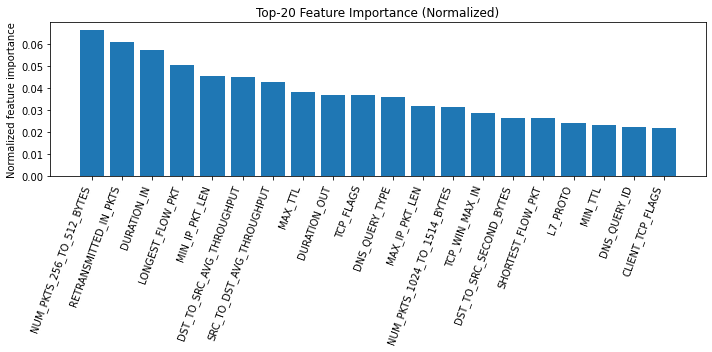

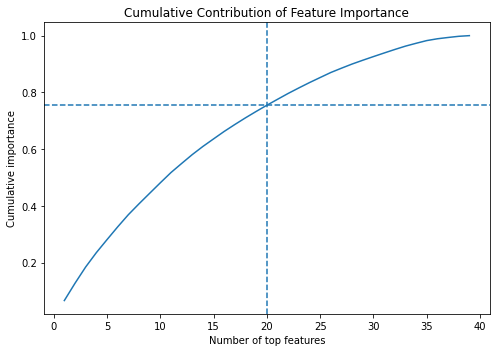

Top-5 contribution:  0.2810
Top-10 contribution: 0.4813
Top-20 contribution: 0.7548


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) 读取你导出的特征重要性文件
# 如果你用的是 attention 权重导出
csv_path = "feature_importance_atten.csv"
df = pd.read_csv(csv_path)

# 如果你用的是RF导出，把上面改成：
# csv_path = "feature_importance_rf.csv"
# df = pd.read_csv(csv_path)
# 并把下面的 col_norm 改成 'rf_importance'

# 2) 选择要画的“归一化重要性”列
# attention文件一般是 importance_norm
col_norm = "importance_norm"

# 3) 排序
df = df.sort_values(col_norm, ascending=False).reset_index(drop=True)

# ===== 图1：Top-K 特征重要性条形图 =====
K = 20
topk = df.head(K).copy()

plt.figure(figsize=(10, 5))
plt.bar(range(K), topk[col_norm].values)
plt.xticks(range(K), topk["feature"].values, rotation=70, ha="right")
plt.ylabel("Normalized feature importance")
plt.title(f"Top-{K} Feature Importance (Normalized)")
plt.tight_layout()
plt.savefig('Top-20 Feature Importanc.jpg',dpi=300)
plt.show()

# ===== 图2：累积贡献曲线（证明“前10个特征贡献很大”）=====
imp = df[col_norm].values
cum = np.cumsum(imp)

plt.figure(figsize=(7, 5))
plt.plot(np.arange(1, len(cum) + 1), cum)
plt.axvline(20, linestyle="--")  # Top-10
plt.axhline(cum[19], linestyle="--")  # Top-10 对应贡献
plt.xlabel("Number of top features")
plt.ylabel("Cumulative importance")
plt.title("Cumulative Contribution of Feature Importance")
plt.tight_layout()
plt.savefig('Cumulative Contribution.jpg',dpi=300)
plt.show()

print(f"Top-5 contribution:  {cum[4]:.4f}")
print(f"Top-10 contribution: {cum[9]:.4f}")
print(f"Top-20 contribution: {cum[19]:.4f}")




In [34]:
th.save(model.state_dict(),'A-SAGE-R_b-64-1100.pth')

In [38]:
model.load_state_dict(th.load('A-SAGE-R_b-64-700.pth'))

<All keys matched successfully>

In [11]:
graphs, _ = dgl.load_graphs('test_b.bin')
G_test = graphs[0]

In [13]:
G_test = G_test.to(device)
node_features_test = G_test.ndata['h']
edge_features_test = G_test.edata['h']
edge_label_test = G_test.edata['label']


In [18]:
#64-700
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
out = model( G_test, node_features_test, edge_features_test)
out = F.softmax(out, dim=1)
_, pred = out.max(dim=1)
acc = accuracy_score(edge_label_test.cpu().numpy(), pred.cpu().numpy())
precision = precision_score(edge_label_test.cpu().numpy(), pred.cpu().numpy())
recall = recall_score(edge_label_test.cpu().numpy(), pred.cpu().numpy())
f1 = f1_score(edge_label_test.cpu().numpy(), pred.cpu().numpy())
print(f'Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}')

Accuracy: 0.9990, Precision: 0.9992, Recall: 0.9998, F1-score: 0.9995
